In [67]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [68]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-22,311.109985,0.0,311.109985,0.0,317.630005,310.359985,317.489990,0.0,35242300
2025-04-23,303.649994,0.0,303.649994,0.0,304.739990,300.589996,304.179993,0.0,25421500


In [69]:
finbert_score = pd.read_csv("Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [70]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [71]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [72]:
merged_df = pd.merge(
    finbert_score, gold_data, left_on="Date", right_on="Date", how="inner"
)

In [73]:
df = merged_df[["Date", "Open"]]

df

,Date,Open
0,2004-11-18,44.430000
1,2004-11-19,44.490002
2,2004-11-22,44.750000
3,2004-11-23,44.880001
4,2004-11-24,44.930000
...,...,...
2914,2019-01-25,122.019997
2915,2019-01-28,122.750000
2916,2019-01-30,123.910004
2917,2019-01-31,125.180000


In [74]:
# make date the index
df.index = df.pop("Date")
df

,Open
Date,
2004-11-18,44.430000
2004-11-19,44.490002
2004-11-22,44.750000
2004-11-23,44.880001
2004-11-24,44.930000
...,...
2019-01-25,122.019997
2019-01-28,122.750000
2019-01-30,123.910004


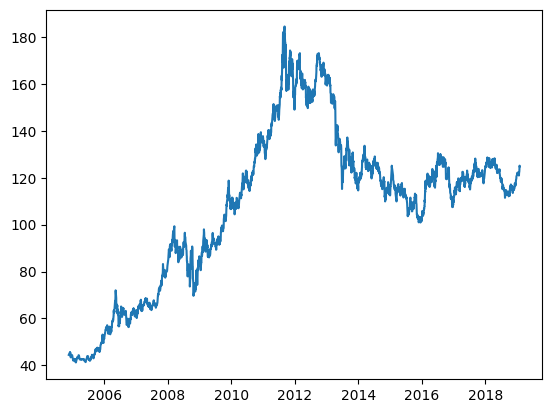

In [75]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Open"])

In [76]:
import numpy as np
import pandas as pd


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe)):
        window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

        if len(window) != n + 1:
            continue  # skip if not enough data

        values = window[["Open"]].to_numpy()
        x, y = values[:-1], values[-1][0]

        dates.append(dataframe.index[i])  # the date corresponding to the target
        X.append(x.flatten())  # flatten to 1D array of n values
        Y.append(y)

    ret_df = pd.DataFrame({"Target Date": dates})

    X = np.array(X)  # shape (num_samples, n)
    for i in range(n):
        ret_df[f"Target-{n - i}"] = X[:, i]  # each column is Open value at t-n+i

    ret_df["Target"] = Y

    return ret_df

In [77]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,44.430000,44.490002,44.750000,44.880001
1,2004-11-24,44.490002,44.750000,44.880001,44.930000
2,2004-11-29,44.750000,44.880001,44.930000,45.099998
3,2004-11-30,44.880001,44.930000,45.099998,45.369999
4,2004-12-01,44.930000,45.099998,45.369999,45.279999
...,...,...,...,...,...
2911,2019-01-25,122.279999,120.959999,121.160004,122.019997
2912,2019-01-28,120.959999,121.160004,122.019997,122.750000
2913,2019-01-30,121.160004,122.019997,122.750000,123.910004
2914,2019-01-31,122.019997,122.750000,123.910004,125.180000


In [78]:
df

,Open
Date,
2004-11-18,44.430000
2004-11-19,44.490002
2004-11-22,44.750000
2004-11-23,44.880001
2004-11-24,44.930000
...,...
2019-01-25,122.019997
2019-01-28,122.750000
2019-01-30,123.910004


In [79]:
# date, Input -> X, output -> Y
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    # getting the dates
    dates = df_as_np[:, 0]

    # we want the target window columns only and not the last one
    middle_matrix = df_as_np[:, 1:-1]
    # we need to reshape this
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    # ouput vector
    Y = df_as_np[:, -1]

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((2916,), (2916, 3, 1), (2916,))

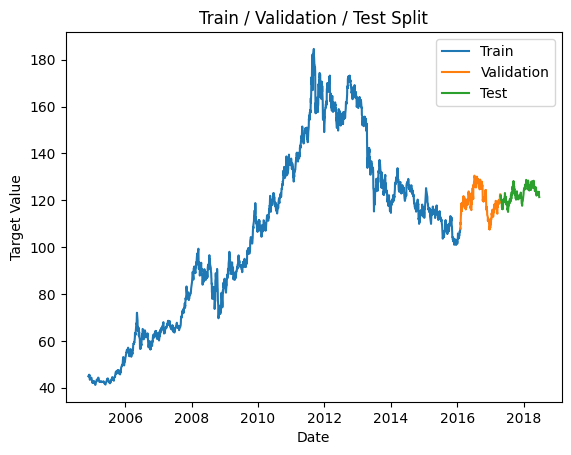

In [80]:
# training part
q_75 = int(len(dates) * 0.75)

# validation part
q_85 = int(len(dates) * 0.85)

# testing part
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_75], X[:q_75], y[:q_75]
dates_val, X_val, y_val = dates[q_75:q_85], X[q_75:q_85], y[q_75:q_85]
dates_test, X_test, y_test = dates[q_85:q_95], X[q_85:q_95], y[q_85:q_95]
dates_hold, X_hold, y_hold = dates[q_95:], X[q_95:], y[q_95:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.title("Train / Validation / Test Split")
plt.show()

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 1)),  # window size = 3, feature = 1
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12827.1406 - mean_absolute_error: 107.0415 - val_loss: 11570.1807 - val_mean_absolute_error: 107.4203
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7130.7134 - mean_absolute_error: 73.1596 - val_loss: 103.9041 - val_mean_absolute_error: 8.9530
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 804.1055 - mean_absolute_error: 21.5032 - val_loss: 2.7890 - val_mean_absolute_error: 1.3264
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.1403 - mean_absolute_error: 1.8884 - val_loss: 2.5413 - val_mean_absolute_error: 1.2877
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.4717 - mean_absolute_error: 1.4972 - val_loss: 6.7990 - val_mean_absolute_error: 2.3338
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5836 - mean_absolute_error: 1.4079 - val_loss: 1.7280 - val_mean_absolute_error: 0.9824
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.1702 - mean_absolute_err

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


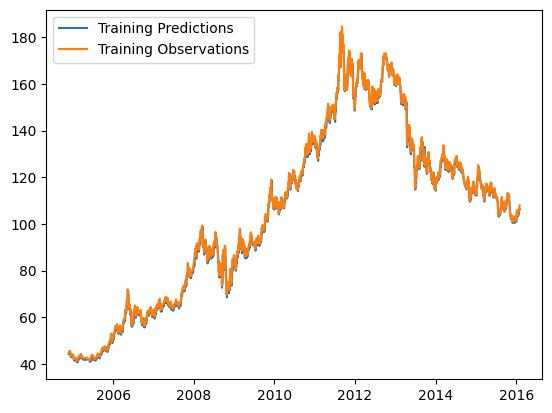

In [82]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

In [83]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
)
import numpy as np

mae = mean_absolute_error(y_train, train_predictions)
mse = mean_squared_error(y_train, train_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_predictions)
mape = mean_absolute_percentage_error(y_train, train_predictions)
explained_var = explained_variance_score(y_train, train_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1965
MSE: 2.6052
RMSE: 1.6141
R² Score: 0.9981
MAPE: 0.0119
Explained Variance: 0.9984


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step


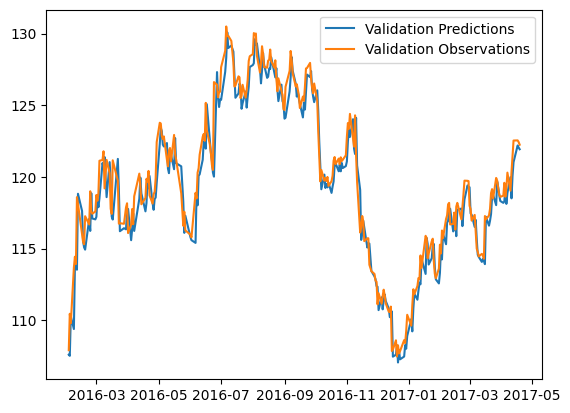

In [84]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

In [85]:
mae = mean_absolute_error(y_val, val_predictions)
mse = mean_squared_error(y_val, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_predictions)
mape = mean_absolute_percentage_error(y_val, val_predictions)
explained_var = explained_variance_score(y_val, val_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 0.9819
MSE: 1.7243
RMSE: 1.3131
R² Score: 0.9417
MAPE: 0.0082
Explained Variance: 0.9497


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


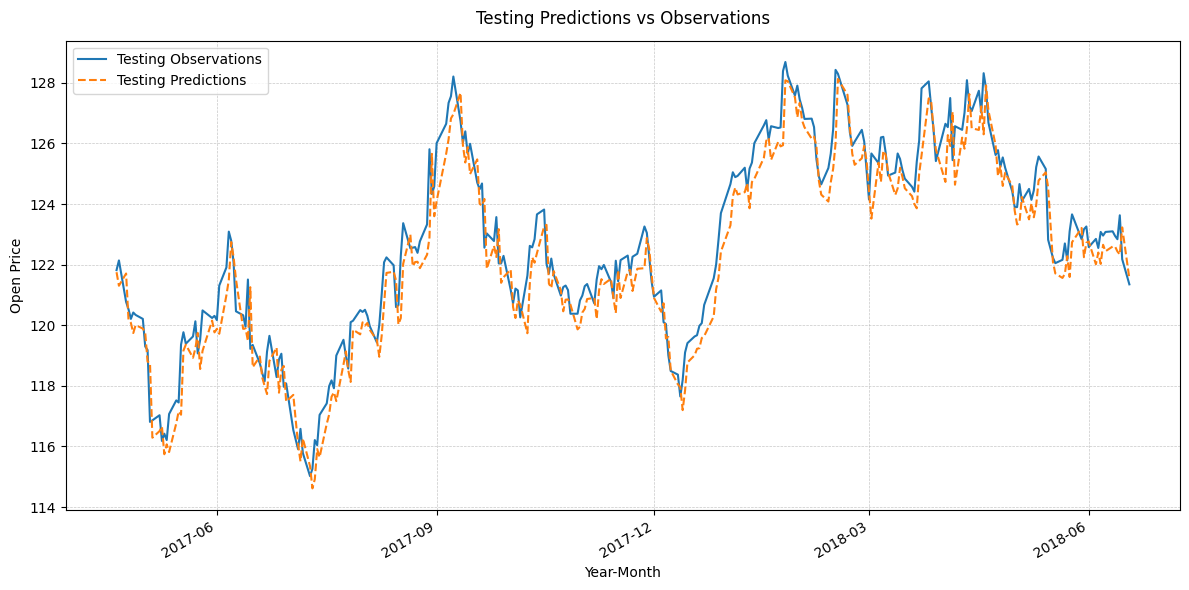

In [86]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# your data
# dates_test, y_test, test_predictions
test_predictions = model.predict(X_test).flatten()

fig, ax = plt.subplots(figsize=(12, 6))

# force a white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# plot the actuals
ax.plot(
    dates_test, y_test, label="Testing Observations", color="tab:blue", linewidth=1.5
)

# plot the preds
ax.plot(
    dates_test,
    test_predictions,
    label="Testing Predictions",
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
)

# labels & title
ax.set_xlabel("Year-Month")
ax.set_ylabel("Open Price")
ax.set_title("Testing Predictions vs Observations", pad=12)

# legend
ax.legend(loc="upper left")

# dashed grid
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)

# nice date formatting
# choose a locator (e.g. every 3 months) or leave default
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# format as YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# rotate if needed
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [87]:
# y_test and test_predictions should be 1D arrays or Series
mae = mean_absolute_error(y_test, test_predictions)

# MAE % relative to the mean of actuals
mae_pct = mae / np.mean(y_test) * 100

# Directional Accuracy: how often the model gets the up/down move right
actual_dir = np.sign(np.diff(y_test))
pred_dir = np.sign(np.diff(test_predictions))
directional_accuracy = np.mean(actual_dir == pred_dir)

# R² score
r2 = r2_score(y_test, test_predictions)

# print them out
print(f"MAE: {mae:.4f}")
print(f"MAE %: {mae_pct:.2f}%")
print(f"Directional Accuracy: {directional_accuracy:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.7228
MAE %: 0.59%
Directional Accuracy: 0.4845
R² Score: 0.9175


In [88]:
# take the sign of the step-to-step changes
actual_dir = np.sign(np.diff(y_test))
pred_dir = np.sign(np.diff(test_predictions))

directional_accuracy = np.mean(actual_dir == pred_dir)
print(f"Directional Accuracy: {directional_accuracy:.4f}")

Directional Accuracy: 0.4845
